# Neural Network: Feed-Forward Network with PyTorch

## Preprocessing for Neural Networks

Neural networks have different requirements than tree-based models:

- **Cannot handle NaN**: Tensor operations require numeric values
- **Sensitive to scale**: Gradient descent works better with normalized inputs
- **Can learn missingness patterns**: With explicit indicator features

The "Zero Imputation with Flags" strategy addresses these requirements:
- Fill all missing numeric values with 0
- Keep ALL `_measured` flags as features
- Apply standard scaling after imputation

The network learns to interpret the combination of (value=0, measured=False) as "missing" rather than "truly zero".

## Data Loading and Preprocessing

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.data_loader import load_thyroid_data_3_classes
from src.preprocessing import get_zero_imputation_with_flags_pipeline
from src.metrics import thyroid_scorer, thyroid_disease_f2_score

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

/media/DIURNOext4/alejandro/wip-clase/PIA-SAA/example_repos/thyroid/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cross validation would be reasonable for this small dataset and for coherence with the previous models but, it's less common with deep learning (also because deep learning doen't normally perform better in tabular data as this). So we implement a tipical simpler train-val-test split.

In [2]:
X_train_full, X_test, y_train_full, y_test = load_thyroid_data_3_classes(test_size=0.15, random_state=42)

# Create validation set from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print(f"Training: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples (held out)")

Training: 6626 samples
Validation: 1170 samples
Test: 1376 samples (held out)


In [3]:
preprocessor = get_zero_imputation_with_flags_pipeline()

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Number of features after preprocessing: {X_train_processed.shape[1]}")

Number of features after preprocessing: 28


In [4]:
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"Classes: {label_encoder.classes_}")

Classes: ['hyperthyroid' 'hypothyroid' 'negative']


## PyTorch Data Preparation

In [5]:
X_train_tensor = torch.tensor(X_train_processed.astype(np.float32))
X_val_tensor = torch.tensor(X_val_processed.astype(np.float32))
X_test_tensor = torch.tensor(X_test_processed.astype(np.float32))

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## ThyroidNet Architecture

We design a simple feed-forward network with:

- **Batch Normalization**: Helps with training stability and acts as regularization
- **Dropout**: Prevents overfitting by randomly zeroing activations
- **ReLU activations**: Standard non-linearity for hidden layers
- **Progressively smaller layers**: Feature compression toward the output

In [6]:
class ThyroidNet(nn.Module):
    
    def __init__(self, input_size: int, num_classes: int = 3, dropout_rate: float = 0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [7]:
n_features = X_train_processed.shape[1]
n_classes = len(label_encoder.classes_)

model = ThyroidNet(n_features, n_classes)
print(model)

ThyroidNet(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)


## Training Setup

In [8]:
import torch
import numpy as np
# Compute class weights to handle severe 90% negative imbalance
class_counts = np.bincount(y_train_encoded)
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_counts)  # Normalize

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training Loop

In [9]:
num_epochs = 100

train_losses = []
val_losses = []
val_recalls = []

best_val_recall = 0
best_model_state = None

for epoch in range(num_epochs):
    # Training phase
    model.train()
    total_train_loss = 0
    num_batches = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        num_batches += 1
    
    avg_train_loss = total_train_loss / num_batches
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_loss_total = 0
        val_predictions = []
        val_targets = []
        
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss_total += loss.item()
            
            predictions = outputs.argmax(dim=1)
            val_predictions.extend(predictions.numpy())
            val_targets.extend(y_batch.numpy())
        
        avg_val_loss = val_loss_total / len(val_loader)
        val_losses.append(avg_val_loss)
        
        val_recall = thyroid_disease_f2_score(np.array(val_targets), np.array(val_predictions))
        val_recalls.append(val_recall)
        
        # Save best model
        if val_recall > best_val_recall:
            best_val_recall = val_recall
            best_model_state = model.state_dict().copy()
    
    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f}")
        print(f"  Val Recall: {val_recall:.4f}")

print(f"\nTraining complete!")
print(f"Best validation recall: {best_val_recall:.4f}")

Epoch [20/100]
  Train Loss: 0.1884
  Val Loss: 0.1764
  Val Recall: 0.8202
Epoch [40/100]
  Train Loss: 0.1525
  Val Loss: 0.2623
  Val Recall: 0.8113
Epoch [60/100]
  Train Loss: 0.1281
  Val Loss: 0.3234
  Val Recall: 0.7877
Epoch [80/100]
  Train Loss: 0.1208
  Val Loss: 0.2493
  Val Recall: 0.8187
Epoch [100/100]
  Train Loss: 0.1199
  Val Loss: 0.2653
  Val Recall: 0.8444

Training complete!
Best validation recall: 0.8566


## Training Curves

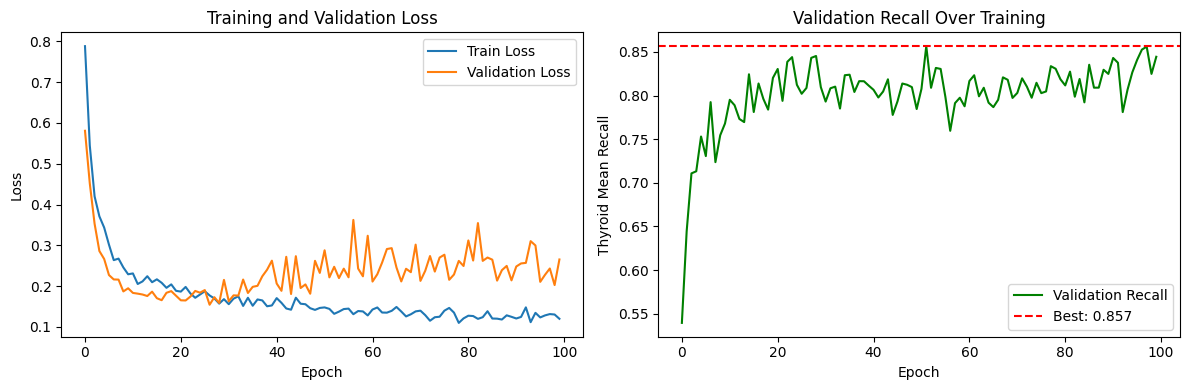

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

# Recall curve
axes[1].plot(val_recalls, label='Validation Recall', color='green')
axes[1].axhline(y=best_val_recall, color='red', linestyle='--', label=f'Best: {best_val_recall:.3f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Thyroid Mean Recall')
axes[1].set_title('Validation Recall Over Training')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation with Best Model

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Get validation predictions
with torch.no_grad():
    val_outputs = model(X_val_tensor)
    val_predictions = val_outputs.argmax(dim=1).numpy()

print("Neural Network - Classification Report:")
print(classification_report(
    y_val_encoded, val_predictions,
    target_names=label_encoder.classes_,
    zero_division=0
))

Neural Network - Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.56      0.94      0.70        31
 hypothyroid       0.61      0.96      0.75        85
    negative       0.99      0.93      0.96      1054

    accuracy                           0.93      1170
   macro avg       0.72      0.94      0.80      1170
weighted avg       0.96      0.93      0.94      1170



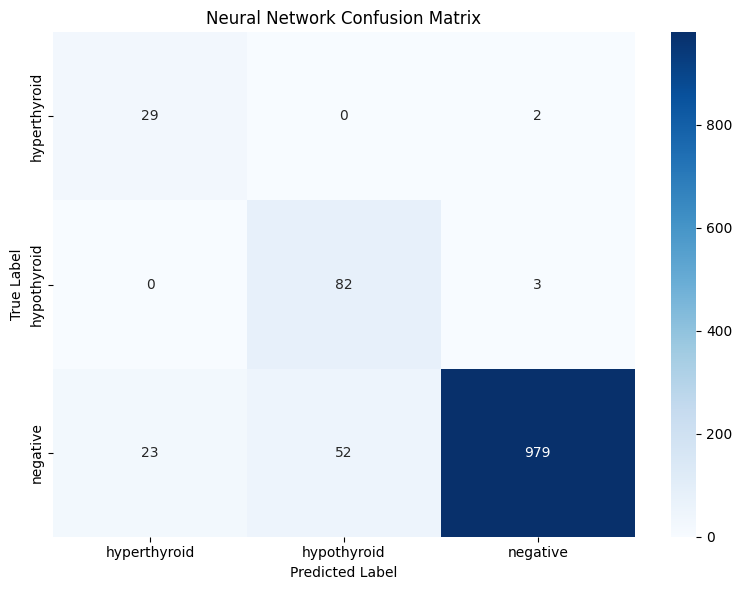

In [12]:
cm = confusion_matrix(y_val_encoded, val_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Neural Network Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Comparison with Tree-Based Models

In [13]:
print(f"Neural Network (best): {best_val_recall:.3f}")
print(f"\nNote: Compare with XGBoost/CatBoost results from notebook 03.")
print(f"Tree-based models typically perform well on structured tabular data.")

Neural Network (best): 0.857

Note: Compare with XGBoost/CatBoost results from notebook 03.
Tree-based models typically perform well on structured tabular data.


## Conclusions

**Key Observations:**

- Neural networks can achieve competitive performance on tabular data
- The zero-imputation-with-flags strategy allows NNs to learn missingness patterns
- Training requires more hyperparameter tuning compared to tree-based models
- Tree ensembles often remain competitive or superior for structured data

**Trade-offs:**

| Aspect | Neural Networks | Tree Ensembles |
|--------|-----------------|----------------|
| Missing values | Requires explicit handling | Native support |
| Feature scaling | Required | Not required |
| Interpretability | Black box | Feature importance available |
| Training speed | Slower (GPU helps) | Generally faster |
| Hyperparameters | Many to tune | Fewer, often works well out-of-box |